In [35]:
import torch
from torch import nn # contains all the blocks for neural networks
import matplotlib.pyplot as plt



In [36]:
'''
Preparing and loading Data 
Create known parameters

'''

#inputs 

weight = 0.7 
bias = 0.3


#Create Data 
start = 0
end = 1
step = 0.02
X = torch.arange (start, end, step).unsqueeze(dim=1) #unsqueeze adds extra dimensions. 
                                                     #Try removing the unsqueeze to see the results
                                                     
#output
y = weight * X + bias

# Debugging

#X[:10], y[:10] 
#slen(X), len(y) 

In [37]:
'''

Spliting data into training and test sets (The #1 thing to take into account when managing data)

Total data = 50

Create a train/test split

'''

train_split = int(0.8 *len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

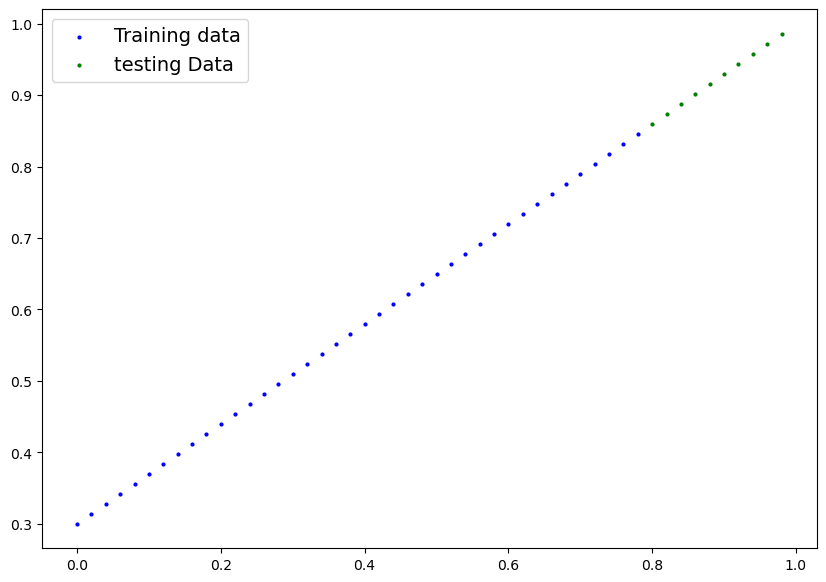

In [38]:
def plot_prediction (train_data =X_train, 
                     train_labels = y_train,
                     test_data = X_test,
                     test_label = y_test,
                     predictions = None) :
    
    plt.figure (figsize= (10, 7))
    
    #Plot training data
    plt.scatter(train_data, train_labels, c ="b", s=4, label = "Training data")
    
    #Plot test data
    plt.scatter(test_data, test_label, c="g", s =4 , label="testing Data")
    
    
    #R there predictions
    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', label = "predictions")
    
    plt.legend(prop ={"size" :14})
    
plot_prediction()

## Build Models 

Check for more information: 
1. Gradient Descent
2. Backpropagation 

*Both are implemented to improve our models*

In [39]:
# Create a linear regression modal class 

class LinearRegressionModel(nn.Module):  # <- Hereda de nn.Module
    def __init__(self):
        super().__init__()
        
        # Inicializar los parámetros del modelo
        self.weight = nn.Parameter(torch.randn(1, 
                                               requires_grad=True,  # Requiere gradiente
                                               dtype=torch.float))  # float32 por defecto
        self.bias = nn.Parameter(torch.randn(1, 
                                             requires_grad=True,  # Para descenso por gradiente
                                             dtype=torch.float))
        
    # Método forward define la operación del modelo
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias  # Esta es la ecuación de regresión lineal

        
         

#### Pytorch model building essentials

* torch.nn : contains all buildings for compuitational neural networks
* torch.nn.parameter: Parameters should our model try and learn
* torch.nn.Module : Base class for all neural network modules, you should write a forward function
* torch.optim : where the optimizers in Pytorch live, they help gradient descent 
* def foward () : All nn.Module subclasses requieres Forward function


In [40]:
#To check whats inside of our neural network

# Create a random seed 
torch.manual_seed(42) #TO get reproducable results

#Create instance of our model 
model_0 = LinearRegressionModel()

#Check out paramters
list(model_0.parameters())

#List name parameters
weight, bias 

(0.7, 0.3)

#### Making predictions using *torch.inference_mode()* 

To check our model's prediction, we must see how it predicts  y_test and X_test

When we pass data through our mordel, it going to run through the Forward method

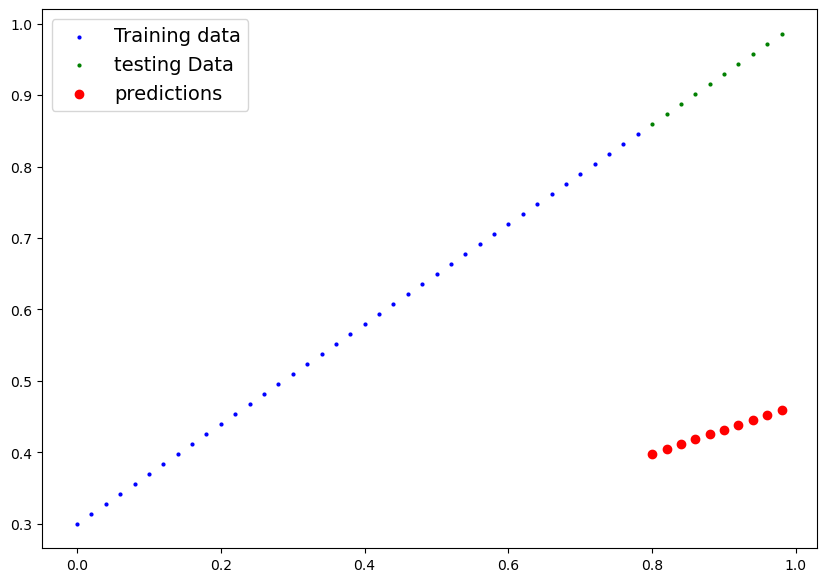

In [41]:
'''
Make predictions
Note that these results will be terrible
'''
with torch.inference_mode():
    y_preds = model_0(X_test)
    
y_preds

y_test

plot_prediction(predictions=y_preds)

#### 3. Train Model

The idea of training is for a model to go from *unknown* parameters to *known* paramters 

Or from a poor representation of the data to a better representation

To measure how bad your prediction are is using loss function

To train models : 
1.  **Loss Function** : Function to measure how wrong your predictions are to your ideal model
2. **optimizer** : Takes into account the loss and adjust the model parameters to improve loss function

For pytorch: 
* training loop
* Testing loop

In [42]:

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [43]:
#Set up a loss function

loss_fn = nn.L1Loss()


#Set up an optimizer (Stochastic gradient descent. For ViT they used Adam)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.001,) #learning rate is the most important hyperparameter (we set it)


### Building a training and testing loop

We need : 
0. Loop through the data
1. Forward pass  
2. Calculate the loss
3. Optimizer zero grad 
4. Loss backward - move backwards through the network to calculate the gradients of the parameters with respect to the loss (**backpropagation**)
5. Optimizer step - Improve the loss (**gradient descent**)


In [69]:
torch.manual_seed(42)

# An epoch is one loop through data 

epochs = 200

#To track the results 
epoch_count =[]
loss_values = []
test_loss_values = []

## Training
# 0 . Loop through the data
for epoch in range (epochs):
    # set the model to training mode 
    model_0.train() #train mode in pytorch set all parameters that requiere gradients to requiere gradients
    
    #1. Foward pass
    y_pred = model_0(X_train)
    
    #2. Calculate loss
    loss = loss_fn(y_pred, y_train) #(input, target)
    #print(f'Loss : {loss}')
    
    #3. Optimizer Zero Grad
    optimizer.zero_grad() #Restarts the value that the optimizer uses. 
    
    #4. Perfor backpropagation on the loss with respect with the parameters of the model
    loss.backward() #We use this because we want a loss function to be 0. 
    
    #5. Step the optimizer - Perform gradient descent
    optimizer.step()  #Optimizer accumulates values. To get value 0 loss. 
    
    
    ## Testing loop
    
    model_0.eval() #turns off settings in the model not needed for testing (dropout,)
    with torch.inference_mode() : #turn off gradient tracking to make our code faster
        # 1. Do the forward pass 
        test_pred = model_0(X_test)
        
        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)
    
    # To know what's happening
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        
        print(f'Epoch:{epoch} \n ; Test : {loss}\n ; test loss : {test_loss}\n')
         
        # Print model state_dict(). This one dictates how close is to our model
        print(model_0.state_dict(),'\n')  #the more epochs, the closer the values to weight and bias
    
   

Epoch:0 
 ; Test : 0.0004444979131221771
 ; test loss : 0.0005780101055279374

OrderedDict([('weight', tensor([0.6997])), ('bias', tensor([0.3008]))]) 

Epoch:10 
 ; Test : 0.0004444979131221771
 ; test loss : 0.0005780101055279374

OrderedDict([('weight', tensor([0.6997])), ('bias', tensor([0.3008]))]) 

Epoch:20 
 ; Test : 0.0004444979131221771
 ; test loss : 0.0005780101055279374

OrderedDict([('weight', tensor([0.6997])), ('bias', tensor([0.3008]))]) 

Epoch:30 
 ; Test : 0.0004444979131221771
 ; test loss : 0.0005780101055279374

OrderedDict([('weight', tensor([0.6997])), ('bias', tensor([0.3008]))]) 

Epoch:40 
 ; Test : 0.0004444979131221771
 ; test loss : 0.0005780101055279374

OrderedDict([('weight', tensor([0.6997])), ('bias', tensor([0.3008]))]) 

Epoch:50 
 ; Test : 0.0004444979131221771
 ; test loss : 0.0005780101055279374

OrderedDict([('weight', tensor([0.6997])), ('bias', tensor([0.3008]))]) 

Epoch:60 
 ; Test : 0.0004444979131221771
 ; test loss : 0.000578010105527937

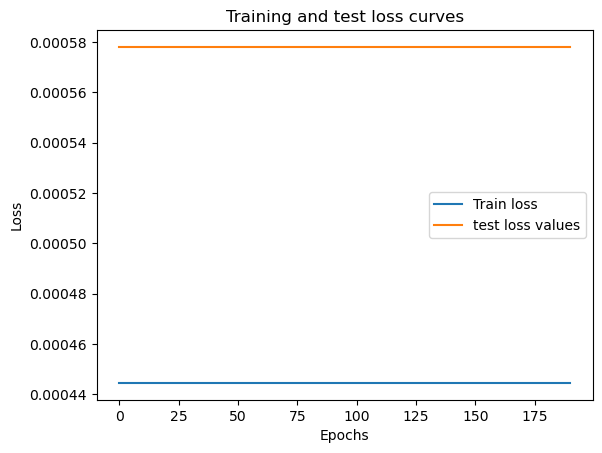

In [70]:

import numpy as np


# Plot the loss curves. To track our model

plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label = "Train loss")
plt.plot(epoch_count, test_loss_values, label = "test loss values")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [46]:
weight, bias

(0.7, 0.3)

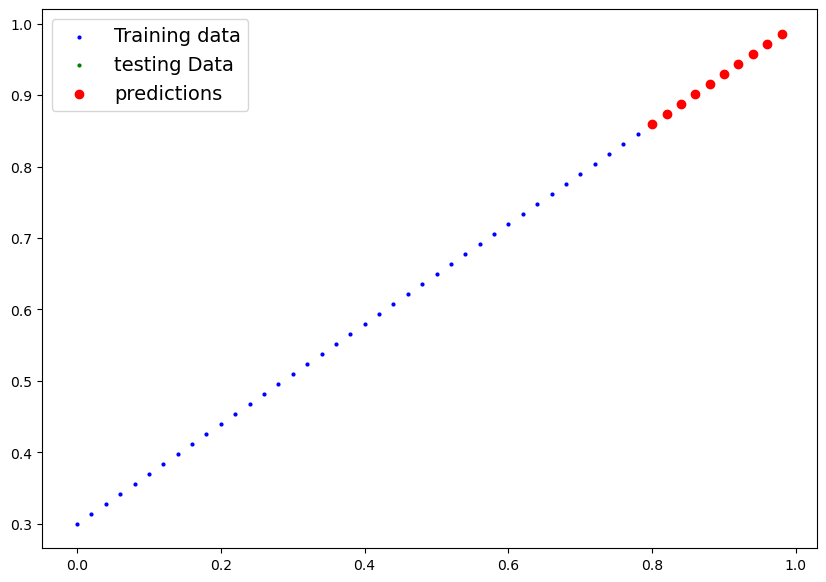

In [71]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

plot_prediction(predictions=y_preds_new)
    

### Save the model

Methods to save and load models : 

1. torch.save() - Allows u save a Pytorch object in Pickle's format
2. torch.load() - Allows u load a saved Pytorch object
3. torch.nn.Module.load_state_dict() - Allows to load a model's saved state dictionary *Recomended*

In [72]:
# Saving Pytorch model

from pathlib import Path

# 1. Create model directory 

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path 

MODEL_NAME = "01_pytorch.pth" #.pth is the objects from pytorch
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

# 3. Save the model 
print(f'Saving model to : {MODEL_SAVE_PATH}\n')
torch.save(obj=model_0.state_dict(), f= MODEL_SAVE_PATH)

Saving model to : models/01_pytorch.pth



##### Loading a Pytorch model 


In [73]:
# To load in a saved state_dict we need a new isntance of our model class

loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


/tmp/ipykernel_30770/707719500.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


<All keys matched successfully>

In [74]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.6994])), ('bias', tensor([0.2998]))])

In [75]:
# Make predictions to be sure

loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8593],
        [0.8733],
        [0.8873],
        [0.9013],
        [0.9152],
        [0.9292],
        [0.9432],
        [0.9572],
        [0.9712],
        [0.9852]])

In [76]:
model_0.eval()

with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.8593],
        [0.8733],
        [0.8873],
        [0.9013],
        [0.9152],
        [0.9292],
        [0.9432],
        [0.9572],
        [0.9712],
        [0.9852]])

In [ ]:
y_preds == loaded_model_preds #should be true all 

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])